![NVIDIA Logo](images/nvidia.png)

# Defining Ports in Custom Stages

In this notebook we'll look at how to explicitly define the number of input and output ports in custom stages. Doing so will lay the groundwork for building custom stages capable either of receiving inputs from multiple stages and/or emitting messages to multiple stages.

---

## Objectives

By the time you complete this notebook you will be able to:

- Define custom stages that can be configured to have more than one input and/or output port.

---

## Imports

In [1]:
import logging
import typing

from IPython.display import Image

from morpheus.config import Config

from morpheus.pipeline import Pipeline
from morpheus.pipeline.execution_mode_mixins import GpuAndCpuMixin
from morpheus.pipeline.pass_thru_type_mixin import PassThruTypeMixin
from morpheus.pipeline.single_port_stage import SinglePortStage

from morpheus.pipeline.stage import Stage

from morpheus.stages.general.monitor_stage import MonitorStage
from morpheus.stages.input.file_source_stage import FileSourceStage
from morpheus.stages.output.in_memory_sink_stage import InMemorySinkStage

from morpheus.utils.logger import configure_logging, reset_logging

import mrc
import mrc.core.operators as ops

---

## Anatomy of a Stage Revisited

You may recall the following image from earlier in the workshop.

![anatomy of a stage](images/anatomy-of-a-stage.png)

Although up until this point in the workshop we have only worked with stages that accept inputs from single stages and emit messages to single stages, we can see in the image that stages are capable to define multiple points of entry (input ports) as well as multiple points of egress (output ports).

---

## Explicitly Definining the Number of Ports

`PassThroughStage` is the same linear pipeline stage we created very early in the workshop. We are going to present it here to make easy the comparison between it and custom stages where we explicitly define the number of input and output ports that a stage has.

In [2]:
class PassThruStage(PassThruTypeMixin, GpuAndCpuMixin, SinglePortStage):
    """A Simple Pass Through Stage"""

    @property
    def name(self) -> str:
        return "pass-thru"

    def accepted_types(self) -> tuple:
        return (typing.Any, )

    def supports_cpp_node(self) -> bool:
        return False

    def on_data(self, message: typing.Any) -> typing.Any:
        return message

    def _build_single(self, builder: mrc.Builder, input_node: mrc.SegmentObject) -> mrc.SegmentObject:
        node = builder.make_node(self.unique_name, ops.map(self.on_data))
        builder.make_edge(input_node, node)

        return node

`NonLinearStage`, by comparison, explicitly defines the number of its input and output ports. We've commented out its defintion below to make clear the differences between it and `PassThruStage` above.

In [3]:
# We no longer inherit from `SinglePortStage` which always defines a single input and output port,
# but rather we now inherit from `Stage` which will allow us to specify the number of input and output ports.
class NonLinearPassThruStage(GpuAndCpuMixin, PassThruTypeMixin, Stage):

    def __init__(self, c: Config):
        super().__init__(c)

        # Classes inheriting from `Stage` need to explicitly define its number of input and output ports
        # using the `_create_ports` method.
        num_input_ports = 1
        num_output_ports = 1
        self._create_ports(num_input_ports, num_output_ports) # Here we define one input port and one output port.

    @property
    def name(self) -> str:
        return "non-linear-pass-thru"

    def supports_cpp_node(self):
        return False
    
    def on_data(self, message: typing.Any) -> typing.Any:
        return message
    

    # We now use `_build` instead of `_build_single` when inheriting from `Stage`.
    # _build now expects a list of type `mrc.SegmentObject` for `input_nodes` since their may be more than one.
    # See `PassThruStage` above for comparison.
    def _build(self, builder: mrc.Builder, input_nodes: list[mrc.SegmentObject]) -> list[mrc.SegmentObject]:
        node = builder.make_node(self.unique_name, ops.map(self.on_data))
        # Since input nodes are now passed in as a list, we need to access them by their index.
        # See `PassThruStage` above for comparison.
        builder.make_edge(input_nodes[0], node)

        # We now return a list of nodes instead of a single node.
        # See `PassThruStage` for comparison.
        return [node]

---

## Build and Run the Passthrough Pipeline

Although we've made some changes in our custom class definition compared to how we did things earlier, we have still created a passthrough stage with a single input port and single output port. Here we build a pipeline to use it and run the pipeline to show that everything still works as expected.

In [4]:
input_file = 'data/simple_user_log.jsonlines'

In [5]:
config = Config()

In [6]:
pipeline = Pipeline(config)

source = pipeline.add_stage(FileSourceStage(config, filename=input_file, iterative=False, repeat=100))
broadcast = pipeline.add_stage(NonLinearPassThruStage(config))
in_mem_sink = pipeline.add_stage(InMemorySinkStage(config))
monitor = pipeline.add_stage(MonitorStage(config, description="Pipeline throughput"))

pipeline.add_edge(source, broadcast)
pipeline.add_edge(broadcast, in_mem_sink)
pipeline.add_edge(in_mem_sink, monitor)

In [7]:
pipeline.build()

In [8]:
viz_file = './pipeline_visualizations/explicit_port_passthrough.png'
pipeline.visualize(viz_file)

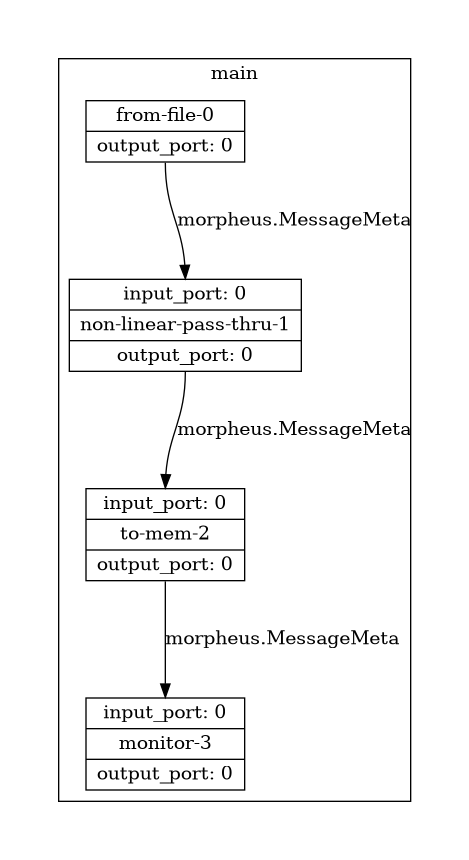

In [9]:
Image(filename=viz_file)

In [10]:
reset_logging()
configure_logging(log_level=logging.DEBUG)

====Starting Pipeline====
====Pipeline Started====


====Building Segment: main====


Added source: <from-file-0; FileSourceStage(filename=data/simple_user_log.jsonlines, iterative=False, file_type=FileTypes.Auto, repeat=100, filter_null=True, filter_null_columns=None, parser_kwargs=None)>
  └─> morpheus.MessageMeta


Added stage: <to-mem-2; InMemorySinkStage()>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta


Added stage: <monitor-3; MonitorStage(description=Pipeline throughput, smoothing=0.05, unit=messages, delayed_start=False, determine_count_fn=None, log_level=LogLevels.INFO)>
  └─ morpheus.MessageMeta -> morpheus.MessageMeta


====Building Segment Complete!====


Pipeline throughput: 0 messages [00:00, ? messages/s]

====Pipeline Complete====


In [11]:
await pipeline.run_async()

Pipeline throughput[Complete]: 1000 messages [00:02, 480.11 messages/s]


In [12]:
messages = in_mem_sink.get_messages()
messages[0].get_data()

,timestamp,user,ip_address,request_time,status,error_message
0,2025-02-01T10:15:30Z,user123,192.168.1.10,200.45,success,<NA>
1,2025-02-01T10:17:00Z,user123,192.168.1.20,150.55,failure,Invalid credentials
2,2025-02-01T10:18:10Z,user456,10.0.0.5,180.60,success,<NA>
3,2025-02-01T10:19:25Z,user789,192.168.1.30,215.25,failure,Timeout
4,2025-02-01T10:20:00Z,user456,10.0.0.6,120.10,success,<NA>
5,2025-02-01T10:22:30Z,user123,192.168.1.40,175.35,failure,Access denied
6,2025-02-01T10:23:45Z,user321,192.168.1.50,205.50,success,<NA>
7,2025-02-01T10:25:05Z,user864,192.168.1.60,190.15,failure,Invalid session
8,2025-02-01T10:26:20Z,user123,192.168.1.70,210.80,success,<NA>
9,2025-02-01T10:27:40Z,user456,10.0.0.7,160.95,failure,Account locked
